# НИРС. Прогнозирование уровня дохода человека на основании уровня образования, семейного положения, рода деятельности и биологических признаков.

## Разведочный анализ данных

In [74]:
import polars as pl

data = pl.read_csv("adult.csv")
data

age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str
90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States""","""<=50K"""
82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States""","""<=50K"""
66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States""","""<=50K"""
54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""
41,"""Private""",264663,"""Some-college""",10,"""Separated""","""Prof-specialty""","""Own-child""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
22,"""Private""",310152,"""Some-college""",10,"""Never-married""","""Protective-serv""","""Not-in-family""","""White""","""Male""",0,0,40,"""United-States""","""<=50K"""
27,"""Private""",257302,"""Assoc-acdm""",12,"""Married-civ-spouse""","""Tech-support""","""Wife""","""White""","""Female""",0,0,38,"""United-States""","""<=50K"""
40,"""Private""",154374,"""HS-grad""",9,"""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""","""Male""",0,0,40,"""United-States""",""">50K"""


In [75]:
data.describe()

statistic,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
str,f64,str,f64,str,f64,str,str,str,str,str,f64,f64,f64,str,str
"""count""",32561.0,"""32561""",32561.0,"""32561""",32561.0,"""32561""","""32561""","""32561""","""32561""","""32561""",32561.0,32561.0,32561.0,"""32561""","""32561"""
"""null_count""",0.0,"""0""",0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0"""
"""mean""",38.581647,null,189778.366512,null,10.080679,null,null,null,null,null,1077.648844,87.30383,40.437456,null,null
"""std""",13.640433,null,105549.977697,null,2.57272,null,null,null,null,null,7385.292085,402.960219,12.347429,null,null
"""min""",17.0,"""?""",12285.0,"""10th""",1.0,"""Divorced""","""?""","""Husband""","""Amer-Indian-Eskimo""","""Female""",0.0,0.0,1.0,"""?""","""<=50K"""
"""25%""",28.0,null,117827.0,null,9.0,null,null,null,null,null,0.0,0.0,40.0,null,null
"""50%""",37.0,null,178356.0,null,10.0,null,null,null,null,null,0.0,0.0,40.0,null,null
"""75%""",48.0,null,237051.0,null,12.0,null,null,null,null,null,0.0,0.0,45.0,null,null
"""max""",90.0,"""Without-pay""",1.484705e6,"""Some-college""",16.0,"""Widowed""","""Transport-moving""","""Wife""","""White""","""Male""",99999.0,4356.0,99.0,"""Yugoslavia""",""">50K"""


## Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.

Удалим признаки `fnlwgt`, `capital.gain`, `capital.loss`, т.к. они имеют большое число пропусков и неинформативны. `education.num` удалим, т.к. он дублирует информацию из поля `education`.

In [76]:
data = data.drop("fnlwgt", "capital.gain", "capital.loss", "education.num")
data

age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
i64,str,str,str,str,str,str,str,i64,str,str
90,"""?""","""HS-grad""","""Widowed""","""?""","""Not-in-family""","""White""","""Female""",40,"""United-States""","""<=50K"""
82,"""Private""","""HS-grad""","""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",18,"""United-States""","""<=50K"""
66,"""?""","""Some-college""","""Widowed""","""?""","""Unmarried""","""Black""","""Female""",40,"""United-States""","""<=50K"""
54,"""Private""","""7th-8th""","""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",40,"""United-States""","""<=50K"""
41,"""Private""","""Some-college""","""Separated""","""Prof-specialty""","""Own-child""","""White""","""Female""",40,"""United-States""","""<=50K"""
…,…,…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Never-married""","""Protective-serv""","""Not-in-family""","""White""","""Male""",40,"""United-States""","""<=50K"""
27,"""Private""","""Assoc-acdm""","""Married-civ-spouse""","""Tech-support""","""Wife""","""White""","""Female""",38,"""United-States""","""<=50K"""
40,"""Private""","""HS-grad""","""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""","""Male""",40,"""United-States""",""">50K"""


Пол респондентов указан текстом, приведем его к числу.

In [77]:
data = data.with_columns(
    pl.col("sex").replace_strict({"Male": 0, "Female": 1}).cast(pl.Int8)
)
data

age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
i64,str,str,str,str,str,str,i8,i64,str,str
90,"""?""","""HS-grad""","""Widowed""","""?""","""Not-in-family""","""White""",1,40,"""United-States""","""<=50K"""
82,"""Private""","""HS-grad""","""Widowed""","""Exec-managerial""","""Not-in-family""","""White""",1,18,"""United-States""","""<=50K"""
66,"""?""","""Some-college""","""Widowed""","""?""","""Unmarried""","""Black""",1,40,"""United-States""","""<=50K"""
54,"""Private""","""7th-8th""","""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""",1,40,"""United-States""","""<=50K"""
41,"""Private""","""Some-college""","""Separated""","""Prof-specialty""","""Own-child""","""White""",1,40,"""United-States""","""<=50K"""
…,…,…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Never-married""","""Protective-serv""","""Not-in-family""","""White""",0,40,"""United-States""","""<=50K"""
27,"""Private""","""Assoc-acdm""","""Married-civ-spouse""","""Tech-support""","""Wife""","""White""",1,38,"""United-States""","""<=50K"""
40,"""Private""","""HS-grad""","""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""",0,40,"""United-States""",""">50K"""


Целевым признаком является доход. В данном датасете данные представлены в виде "доход не больше $50K в год" либо "доход больше $50K в год". Закодируем значения через `0` и `1`.

In [78]:
data = data.with_columns(
    pl.col("income").replace_strict({"<=50K": 0, ">50K": 1}).cast(pl.Int8)
).rename({"income": "income_is_high"})
data

age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income_is_high
i64,str,str,str,str,str,str,i8,i64,str,i8
90,"""?""","""HS-grad""","""Widowed""","""?""","""Not-in-family""","""White""",1,40,"""United-States""",0
82,"""Private""","""HS-grad""","""Widowed""","""Exec-managerial""","""Not-in-family""","""White""",1,18,"""United-States""",0
66,"""?""","""Some-college""","""Widowed""","""?""","""Unmarried""","""Black""",1,40,"""United-States""",0
54,"""Private""","""7th-8th""","""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""",1,40,"""United-States""",0
41,"""Private""","""Some-college""","""Separated""","""Prof-specialty""","""Own-child""","""White""",1,40,"""United-States""",0
…,…,…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Never-married""","""Protective-serv""","""Not-in-family""","""White""",0,40,"""United-States""",0
27,"""Private""","""Assoc-acdm""","""Married-civ-spouse""","""Tech-support""","""Wife""","""White""",1,38,"""United-States""",0
40,"""Private""","""HS-grad""","""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""",0,40,"""United-States""",1


In [79]:
data.get_column("native.country").value_counts(sort=True)

native.country,count
str,u32
"""United-States""",29170
"""Mexico""",643
"""?""",583
"""Philippines""",198
"""Germany""",137
…,…
"""Outlying-US(Guam-USVI-etc)""",14
"""Honduras""",13
"""Hungary""",13


Распределение по странам крайне неравномерное: около 90% записей представляют один класс - жителей США. Данный факт может сильно сказываться на качестве будущих моделей. Оставим в датасете только людей из США.

In [80]:
data = data.filter(pl.col("native.country") == "United-States").drop("native.country")
data

age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,income_is_high
i64,str,str,str,str,str,str,i8,i64,i8
90,"""?""","""HS-grad""","""Widowed""","""?""","""Not-in-family""","""White""",1,40,0
82,"""Private""","""HS-grad""","""Widowed""","""Exec-managerial""","""Not-in-family""","""White""",1,18,0
66,"""?""","""Some-college""","""Widowed""","""?""","""Unmarried""","""Black""",1,40,0
54,"""Private""","""7th-8th""","""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""",1,40,0
41,"""Private""","""Some-college""","""Separated""","""Prof-specialty""","""Own-child""","""White""",1,40,0
…,…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Never-married""","""Protective-serv""","""Not-in-family""","""White""",0,40,0
27,"""Private""","""Assoc-acdm""","""Married-civ-spouse""","""Tech-support""","""Wife""","""White""",1,38,0
40,"""Private""","""HS-grad""","""Married-civ-spouse""","""Machine-op-inspct""","""Husband""","""White""",0,40,1


In [81]:
data.get_column("race").value_counts(sort=True)

race,count
str,u32
"""White""",25621
"""Black""",2832
"""Amer-Indian-Eskimo""",296
"""Asian-Pac-Islander""",292
"""Other""",129


In [82]:
data = data.filter(pl.col("race").is_in(["White", "Black"])).with_columns(
    pl.col("race").replace_strict({"White": 0, "Black": 1}).cast(pl.Int8)
)
data

age,workclass,education,marital.status,occupation,relationship,race,sex,hours.per.week,income_is_high
i64,str,str,str,str,str,i8,i8,i64,i8
90,"""?""","""HS-grad""","""Widowed""","""?""","""Not-in-family""",0,1,40,0
82,"""Private""","""HS-grad""","""Widowed""","""Exec-managerial""","""Not-in-family""",0,1,18,0
66,"""?""","""Some-college""","""Widowed""","""?""","""Unmarried""",1,1,40,0
54,"""Private""","""7th-8th""","""Divorced""","""Machine-op-inspct""","""Unmarried""",0,1,40,0
41,"""Private""","""Some-college""","""Separated""","""Prof-specialty""","""Own-child""",0,1,40,0
…,…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Never-married""","""Protective-serv""","""Not-in-family""",0,0,40,0
27,"""Private""","""Assoc-acdm""","""Married-civ-spouse""","""Tech-support""","""Wife""",0,1,38,0
40,"""Private""","""HS-grad""","""Married-civ-spouse""","""Machine-op-inspct""","""Husband""",0,0,40,1


In [83]:
data.get_column("marital.status").value_counts(sort=True)

marital.status,count
str,u32
"""Married-civ-spouse""",13117
"""Never-married""",9277
"""Divorced""",4058
"""Widowed""",877
"""Separated""",860
"""Married-spouse-absent""",241
"""Married-AF-spouse""",23


`marital.status` заменим на бинарный признак "состоит в браке".

In [ ]:
data = data.with_columns(
    pl.when(pl.col("marital.status").is_in(["Married-civ-spouse", "Married-AF-spouse"]))
    .then(1)
    .otherwise(0)
    .cast(pl.Int8)
    .alias("is_married")
).drop("marital.status")
data

age,workclass,education,occupation,relationship,race,sex,hours.per.week,income_is_high,is_married
i64,str,str,str,str,i8,i8,i64,i8,i8
90,"""?""","""HS-grad""","""?""","""Not-in-family""",0,1,40,0,0
82,"""Private""","""HS-grad""","""Exec-managerial""","""Not-in-family""",0,1,18,0,0
66,"""?""","""Some-college""","""?""","""Unmarried""",1,1,40,0,0
54,"""Private""","""7th-8th""","""Machine-op-inspct""","""Unmarried""",0,1,40,0,0
41,"""Private""","""Some-college""","""Prof-specialty""","""Own-child""",0,1,40,0,0
…,…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Protective-serv""","""Not-in-family""",0,0,40,0,0
27,"""Private""","""Assoc-acdm""","""Tech-support""","""Wife""",0,1,38,0,1
40,"""Private""","""HS-grad""","""Machine-op-inspct""","""Husband""",0,0,40,1,1


`relationship` сильно зависит от `is_married`. Удаляем.

In [85]:
data = data.drop("relationship")
data

age,workclass,education,occupation,race,sex,hours.per.week,income_is_high,is_married
i64,str,str,str,i8,i8,i64,i8,i8
90,"""?""","""HS-grad""","""?""",0,1,40,0,0
82,"""Private""","""HS-grad""","""Exec-managerial""",0,1,18,0,0
66,"""?""","""Some-college""","""?""",1,1,40,0,0
54,"""Private""","""7th-8th""","""Machine-op-inspct""",0,1,40,0,0
41,"""Private""","""Some-college""","""Prof-specialty""",0,1,40,0,0
…,…,…,…,…,…,…,…,…
22,"""Private""","""Some-college""","""Protective-serv""",0,0,40,0,0
27,"""Private""","""Assoc-acdm""","""Tech-support""",0,1,38,0,1
40,"""Private""","""HS-grad""","""Machine-op-inspct""",0,0,40,1,1


`workclass` сильно зависит от `occupation`. Удаляем.

In [86]:
data = data.drop("workclass")
data

age,education,occupation,race,sex,hours.per.week,income_is_high,is_married
i64,str,str,i8,i8,i64,i8,i8
90,"""HS-grad""","""?""",0,1,40,0,0
82,"""HS-grad""","""Exec-managerial""",0,1,18,0,0
66,"""Some-college""","""?""",1,1,40,0,0
54,"""7th-8th""","""Machine-op-inspct""",0,1,40,0,0
41,"""Some-college""","""Prof-specialty""",0,1,40,0,0
…,…,…,…,…,…,…,…
22,"""Some-college""","""Protective-serv""",0,0,40,0,0
27,"""Assoc-acdm""","""Tech-support""",0,1,38,0,1
40,"""HS-grad""","""Machine-op-inspct""",0,0,40,1,1


Незакодированными остались признаки `education`, `occupation`. Ни один из этих признаков не отражает линейный прогресс в достижении какой-то цели, даже признак образования, к тому же значения в данном столбце не могут быть однозначно упорядочены по уровню образования.

Для каждого из этих столбцов применим OneHot-encoding.

In [87]:
data_to_dummies = data.select("education", "occupation")
data = data.drop("education", "occupation").hstack(data_to_dummies.to_dummies())
data

age,race,sex,hours.per.week,income_is_high,is_married,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
i64,i8,i8,i64,i8,i8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
90,0,1,40,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
82,0,1,18,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
66,1,1,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
54,0,1,40,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
41,0,1,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
22,0,0,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
27,0,1,38,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
40,0,0,40,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


Признаки `age` и `hours.per.week` отмасштабируем с помощью MinMax-скейлинга.

In [88]:
import pickle

from sklearn.preprocessing import MinMaxScaler

age_scaler = MinMaxScaler()
hours_scaler = MinMaxScaler()

data = data.with_columns(
    pl.col("age").map_batches(
        lambda x: age_scaler.fit_transform(x.reshape((-1, 1))).ravel(),
    ),
    pl.col("hours.per.week").map_batches(
        lambda x: hours_scaler.fit_transform(x.reshape((-1, 1))).ravel(),
    ),
)
with open("assets/age_scaler.pkl", "wb") as f:
    pickle.dump(age_scaler, f)

with open("assets/hours_scaler.pkl", "wb") as f:
    pickle.dump(hours_scaler, f)

data

age,race,sex,hours.per.week,income_is_high,is_married,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
f64,i8,i8,f64,i8,i8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
1.0,0,1,0.397959,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0.890411,0,1,0.173469,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
0.671233,1,1,0.397959,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0.506849,0,1,0.397959,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
0.328767,0,1,0.397959,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.068493,0,0,0.397959,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
0.136986,0,1,0.377551,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
0.315068,0,0,0.397959,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


## Проведение корреляционного анализа данных.

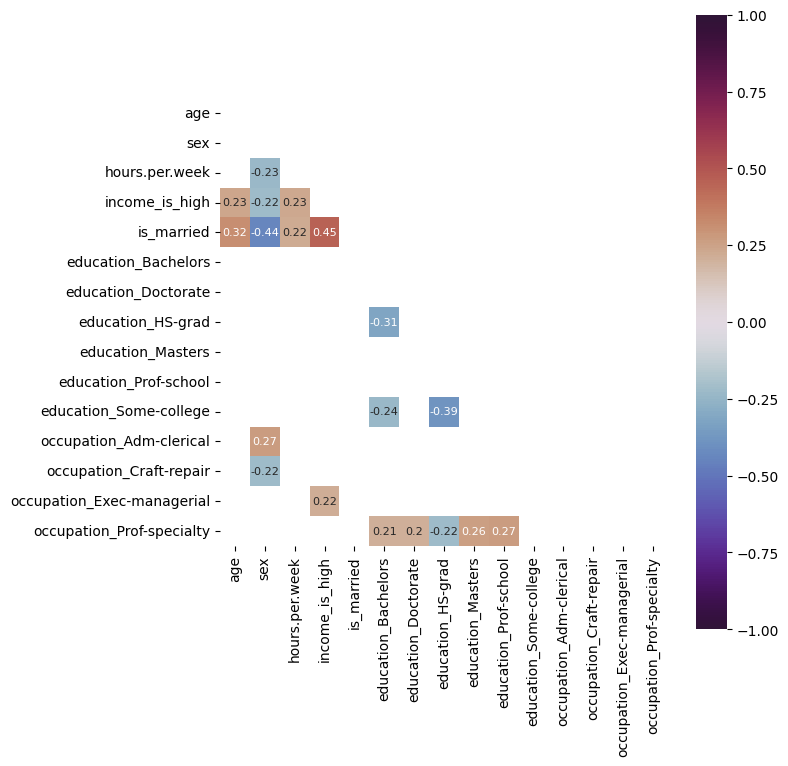

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = data.corr().to_pandas()
threshold = 0.2

corr_filtered = corr.mask(np.eye(corr.shape[0], dtype=bool))
corr_filtered = corr_filtered.where(corr_filtered.abs() >= threshold)

corr_filtered = corr_filtered.dropna(axis=0, how="all")
corr_filtered = corr_filtered.dropna(axis=1, how="all")

plt.figure(figsize=(8, 8))
ax = sns.heatmap(
    corr_filtered,
    cmap="twilight_shifted",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    mask=(np.triu(np.ones_like(corr_filtered, dtype=bool))),
    annot=True,
    annot_kws={"size": 8},
)

ax.set_yticklabels(corr_filtered.columns, rotation=0)

plt.tight_layout()
plt.show()

На корреляционной матрице видим, что доход заметно коррелирует с:

- возрастом;
- полом; 
- количеством рабочих часов;
- состоянием в браке;
- нахождением на руководящей должности.

## Выбор метрик для последующей оценки качества моделей.

Оценка качества будет проводиться следующим набором метрик:

- Accuracy
- F1
- ROC-AUC

Accuracy даёт понятную оценку доли верных классификаций, однако чувствительна к дисбалансу классов.

F1‑мера агрегирует точность (precision) и полноту (recall).

Поскольку задача представляет собой бинарную классификацию с умеренным дисбалансом классов, ROC‑AUC также уместна.

## Выбор наиболее подходящих моделей для решения задачи классификации.

Следующие модели будут рассмотрены:

- Логистическая регрессия
- KNN
- Дерево решений
- RandomForest
- Градиентный бустинг (в виде CatBoost от Яндекс)

## Формирование обучающей и тестовой выборок на основе исходного набора данных.

In [90]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    data.drop("income_is_high"),
    data.get_column("income_is_high"),
    test_size=0.2,
    random_state=42,
    stratify=data.get_column("income_is_high"),
)

In [91]:
with open("assets/X_train.pkl", "wb") as f:
    pickle.dump(X_train, f)

with open("assets/y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open("assets/X_test.pkl", "wb") as f:
    pickle.dump(X_test, f)

with open("assets/y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

## Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров

In [59]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


lr = LogisticRegression(random_state=42)
svc = LinearSVC(random_state=42)
dt = DecisionTreeClassifier(random_state=42, min_samples_leaf=1)
rf = RandomForestClassifier(random_state=42)
ct = CatBoostClassifier(random_state=42, verbose=0)


def compare_models(models) -> tuple[pl.DataFrame, object]:
    rows = []
    best_f1 = 0
    best_model = None

    for model in models:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            y_score = None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_score) if y_score is not None else None

        if f1 > best_f1:
            best_f1 = f1
            best_model = model

        rows.append(
            {
                "model": (
                    model.estimator.__class__.__name__
                    if isinstance(model, GridSearchCV)
                    else model.__class__.__name__
                ),
                "accuracy": f"{acc:.3f}",
                "f1": f"{f1:.3f}",
                "roc_auc": f"{roc_auc:.3f}",
                "params": (
                    str(model.best_params_)
                    if isinstance(model, GridSearchCV)
                    else str(model.get_params())
                ),
            }
        )

    return pl.DataFrame(rows), best_model


baseline_df, _ = compare_models([lr, svc, dt, rf, ct])
baseline_df

model,accuracy,f1,roc_auc,params
str,str,str,str,str
"""LogisticRegression""","""0.821""","""0.598""","""0.878""","""{'C': 1.0, 'class_weight': Non…"
"""LinearSVC""","""0.822""","""0.600""","""0.877""","""{'C': 1.0, 'class_weight': Non…"
"""DecisionTreeClassifier""","""0.784""","""0.541""","""0.730""","""{'ccp_alpha': 0.0, 'class_weig…"
"""RandomForestClassifier""","""0.802""","""0.577""","""0.839""","""{'bootstrap': True, 'ccp_alpha…"
"""CatBoostClassifier""","""0.831""","""0.629""","""0.888""","""{'verbose': 0, 'random_state':…"


## Подбор гиперпараметров

In [ ]:
grids = [
    (
        lr,
        {"C": [0.01, 0.1, 1.0]},
    ),
    (
        svc,
        {"C": [0.01, 0.1, 1, 10]},
    ),
    (
        dt,
        {
            "max_depth": [5, 10, None],
            "min_samples_leaf": [5, 10],
            "criterion": ["gini", "entropy", "log_loss"],
        },
    ),
    (
        rf,
        {
            "n_estimators": [200, 500],
            "max_depth": [3, 5, 10, None],
            "min_samples_leaf": [5, 10],
        },
    ),
    (
        ct,
        {
            "iterations": [500, 1000],
            "learning_rate": [0.01, 0.1],
            "depth": [5, 10],
        },
    ),
]

models_with_best_params = []

tuned_df, best_tuned_model = compare_models(
    GridSearchCV(
        model,
        param_grid,
        scoring="f1_macro",
        cv=5,
    )
    for model, param_grid in grids
)

In [ ]:
with open("assets/feature_cols.pkl", "wb") as f:
    pickle.dump(X_train.columns, f)

In [64]:
baseline_df

model,accuracy,f1,roc_auc,params
str,str,str,str,str
"""LogisticRegression""","""0.821""","""0.598""","""0.878""","""{'C': 1.0, 'class_weight': Non…"
"""LinearSVC""","""0.822""","""0.600""","""0.877""","""{'C': 1.0, 'class_weight': Non…"
"""DecisionTreeClassifier""","""0.784""","""0.541""","""0.730""","""{'ccp_alpha': 0.0, 'class_weig…"
"""RandomForestClassifier""","""0.802""","""0.577""","""0.839""","""{'bootstrap': True, 'ccp_alpha…"
"""CatBoostClassifier""","""0.831""","""0.629""","""0.888""","""{'verbose': 0, 'random_state':…"


In [70]:
tuned_df

model,accuracy,f1,roc_auc,params
str,str,str,str,str
"""LogisticRegression""","""0.821""","""0.598""","""0.878""","""{'C': 1.0}"""
"""LinearSVC""","""0.822""","""0.600""","""0.877""","""{'C': 1}"""
"""DecisionTreeClassifier""","""0.823""","""0.595""","""0.865""","""{'criterion': 'entropy', 'max_…"
"""RandomForestClassifier""","""0.829""","""0.612""","""0.887""","""{'max_depth': None, 'min_sampl…"
"""CatBoostClassifier""","""0.830""","""0.625""","""0.889""","""{'depth': 10, 'iterations': 10…"


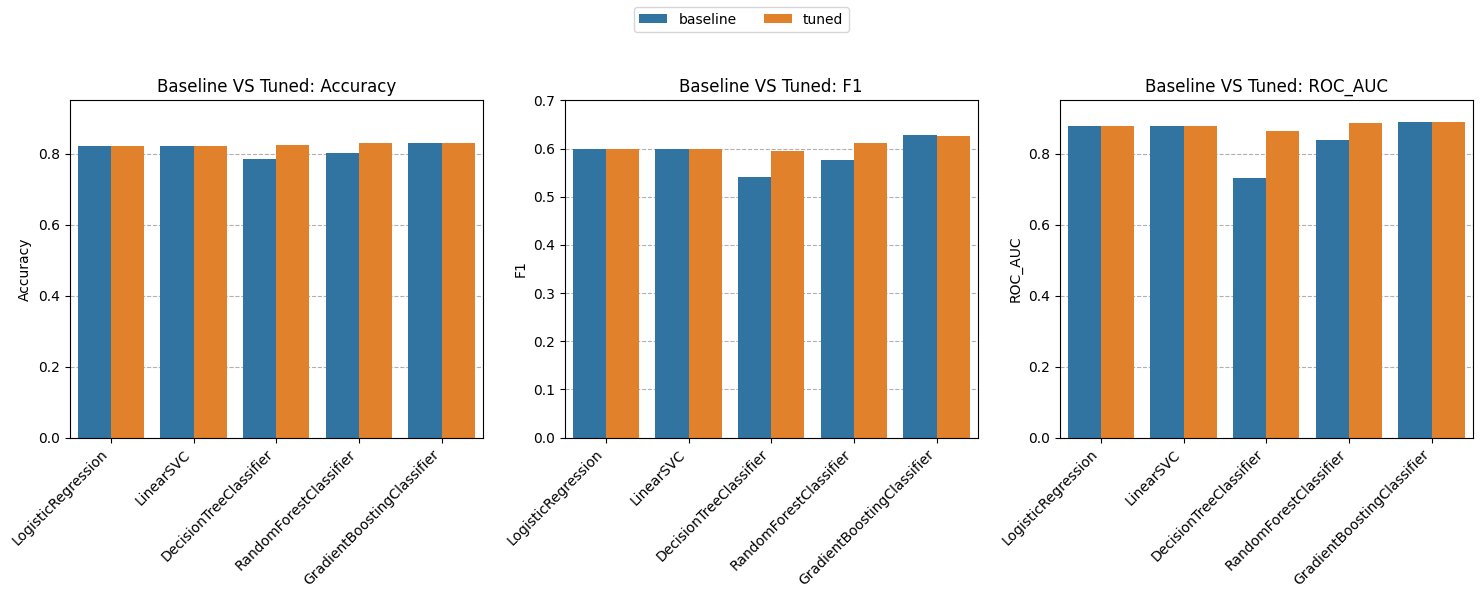

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

baseline_pd = baseline_df.with_columns(
    pl.col("accuracy").cast(pl.Float64),
    pl.col("f1").cast(pl.Float64),
    pl.col("roc_auc").cast(pl.Float64),
).to_pandas()
tuned_pd = tuned_df.with_columns(
    pl.col("accuracy").cast(pl.Float64),
    pl.col("f1").cast(pl.Float64),
    pl.col("roc_auc").cast(pl.Float64),
).to_pandas()


def normalize_name(s: str) -> str:
    if "LogisticRegression" in s:
        return "LogisticRegression"
    if "LinearSVC" in s:
        return "LinearSVC"
    if "DecisionTreeClassifier" in s:
        return "DecisionTreeClassifier"
    if "RandomForestClassifier" in s:
        return "RandomForestClassifier"
    if "CatBoostClassifier" in s:
        return "GradientBoostingClassifier"
    return s


baseline_pd["model_name"] = baseline_pd["model"].astype(str).map(normalize_name)
tuned_pd["model_name"] = tuned_pd["model"].astype(str).map(normalize_name)

baseline_short = baseline_pd[["model_name", "accuracy", "f1", "roc_auc"]].copy()
tuned_short = tuned_pd[["model_name", "accuracy", "f1", "roc_auc"]].copy()

baseline_short["type"] = "baseline"
tuned_short["type"] = "tuned"

both = pd.concat([baseline_short, tuned_short], ignore_index=True)

order = [
    "LogisticRegression",
    "LinearSVC",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
]
both["model_name"] = pd.Categorical(both["model_name"], categories=order, ordered=True)

metrics = ["Accuracy", "F1", "ROC_AUC"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(metrics),
    figsize=(15, 6),
    sharey=False,
)

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=both,
        x="model_name",
        y=metric.lower(),
        hue="type",
        ax=ax,
    )
    ax.set_title(f"Baseline VS Tuned: {metric}")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 0.95 if metric != "F1" else 0.7)

    ax.yaxis.grid(True, linestyle="--")
    ax.set_axisbelow(True)

    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
for ax in axes:
    ax.get_legend().remove()

plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

## Формирование выводов о качестве построенных моделей на основе выбранных метрик

Подбор гиперпараметров заметно повлиял только на дерево решений и случайный лес. Изменения у остальных моделей находятся в пределах погрешности.

Лучший результат показала модель градиентного бустинга (CatBoost): accuracy около 0.83, F1‑мера порядка 0.63 и ROC‑AUC порядка 0.89.